In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned/fast_food_dataset_cleaned.csv")
df.head()

,order_id,timestamp,product_name,category,quantity,unit_price,total_price,payment_method,order_type
0,100000,2024-10-01 07:11:00,Fries (Medium),sides,1.0,2.79,2.79,online,dine-in
1,100001,2024-06-26 04:35:00,Coca-Cola (M),drink,1.0,2.49,2.49,online,dine-in
2,100002,2024-01-21 19:49:00,Sundae Caramel,dessert,3.0,2.49,7.47,online,takeaway
3,100003,2024-09-05 22:17:00,20pc Nuggets,sides,2.0,7.99,15.98,card,dine-in
4,100004,2024-11-21 22:48:00,6pc Nuggets,sides,3.0,3.49,10.47,online,takeaway


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99090 entries, 0 to 99089
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        99090 non-null  int64  
 1   timestamp       99090 non-null  object 
 2   product_name    99090 non-null  object 
 3   category        99090 non-null  object 
 4   quantity        98102 non-null  float64
 5   unit_price      99090 non-null  float64
 6   total_price     98102 non-null  float64
 7   payment_method  97603 non-null  object 
 8   order_type      98096 non-null  object 
dtypes: float64(3), int64(1), object(5)
memory usage: 6.8+ MB


In [3]:
df.describe()

,order_id,quantity,unit_price,total_price
count,99090.000000,98102.000000,99090.000000,98102.000000
mean,149981.592734,1.999653,4.395011,8.787995
std,28864.492541,0.816105,2.515013,6.487499
min,100000.000000,1.000000,0.003833,0.007666
25%,124979.250000,1.000000,2.490000,4.470000
50%,149990.500000,2.000000,3.290000,6.990000
75%,174973.750000,3.000000,6.790000,10.470000
max,199999.000000,3.000000,30.518858,76.385492


In [5]:
total_revenue = df['total_price'].sum()
total_orders = df['order_id'].nunique()
total_items = df['quantity'].sum()

print("=== BUSINESS KPIs ===")
print(f"Total Revenue: €{total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Items Sold: {total_items}")

=== BUSINESS KPIs ===
Total Revenue: €862,119.93
Total Orders: 99000
Total Items Sold: 196170.0


In [6]:
rev_by_cat = df.groupby("category")["total_price"].sum().sort_values(ascending=False)
rev_by_cat

category
burger     312405.714508
sides      222297.362665
drink       97865.695218
combo       93211.352338
kids        88548.219188
dessert     46030.949670
kids         1760.637082
Name: total_price, dtype: float64

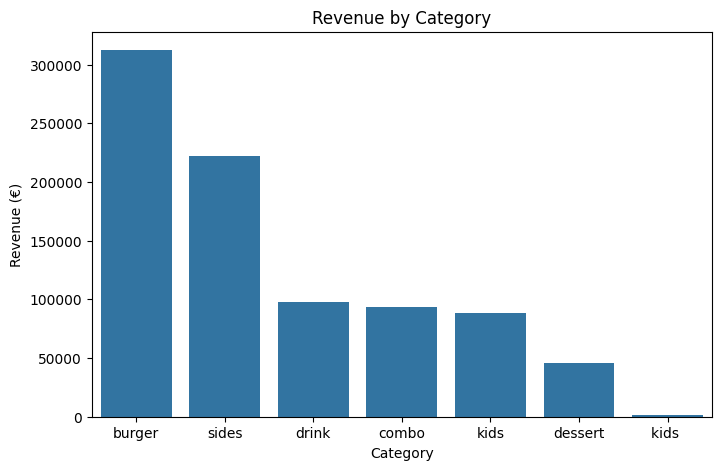

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(x=rev_by_cat.index, y=rev_by_cat.values)
plt.title("Revenue by Category")
plt.ylabel("Revenue (€)")
plt.xlabel("Category")
plt.show()

In [10]:
top_products = df.groupby("product_name")["quantity"].sum().sort_values(ascending=False).head(10)
top_products

product_name
Coca-Cola (M)       9132.0
Big King            8960.0
Chicken Royale      8884.0
Bacon King          8872.0
Sundae Chocolate    8865.0
Kids Nuggets 4pc    8855.0
Whopper             8832.0
Latte (M)           8832.0
Sundae Caramel      8807.0
Whopper Meal        8799.0
Name: quantity, dtype: float64

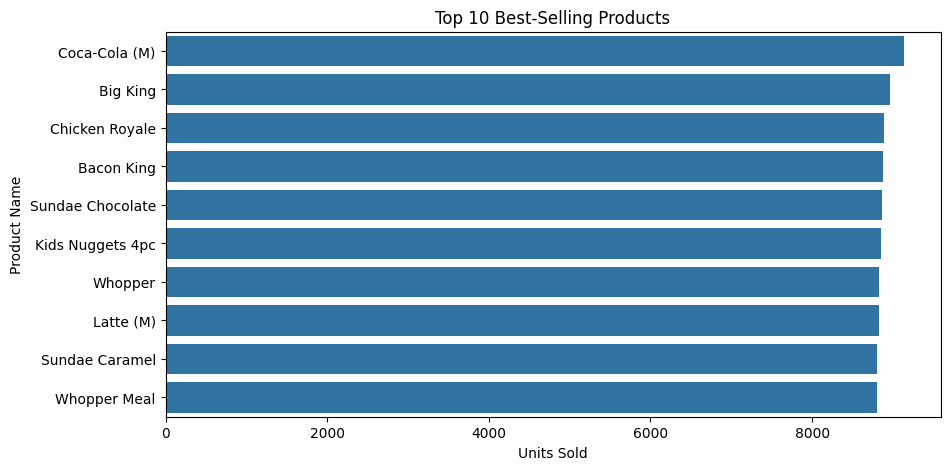

In [11]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Units Sold")
plt.ylabel("Product Name")
plt.show()

In [12]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day_name()
df['weekday'] = df['timestamp'].dt.weekday

In [13]:
rev_by_hour = df.groupby("hour")["total_price"].sum()
rev_by_hour

hour
0     36376.307496
1     35820.478711
2     36297.055448
3     35897.628898
4     36915.985579
5     34568.771012
6     36791.456941
7     37050.134025
8     35386.487988
9     36583.290563
10    36130.783090
11    36553.460781
12    35123.372558
13    34739.095232
14    37289.856247
15    34927.851097
16    35348.792101
17    36874.876539
18    35228.360876
19    35180.834158
20    35900.521860
21    37025.416481
22    35100.234346
23    35008.878641
Name: total_price, dtype: float64

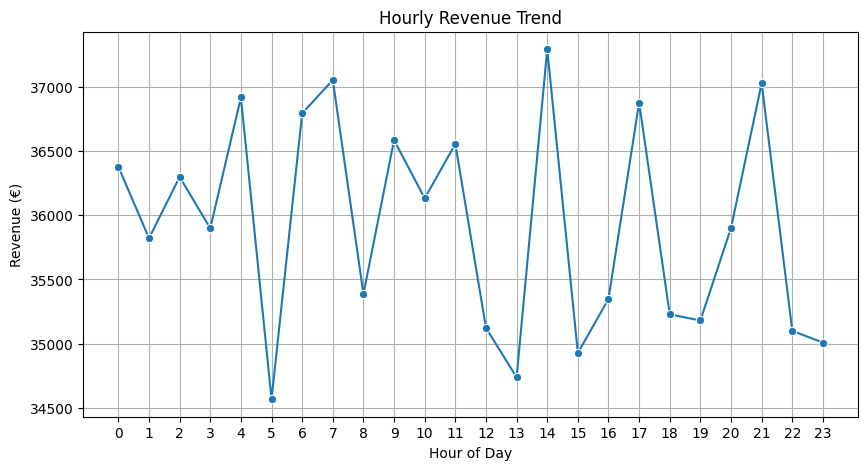

In [14]:
plt.figure(figsize=(10,5))
sns.lineplot(x=rev_by_hour.index, y=rev_by_hour.values, marker="o")
plt.title("Hourly Revenue Trend")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue (€)")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

In [15]:
rev_by_day = df.groupby("day")["total_price"].sum().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)
rev_by_day

day
Monday       124863.752452
Tuesday      122261.222770
Wednesday    123280.910968
Thursday     122925.341827
Friday       122922.055715
Saturday     122220.209648
Sunday       123646.437289
Name: total_price, dtype: float64

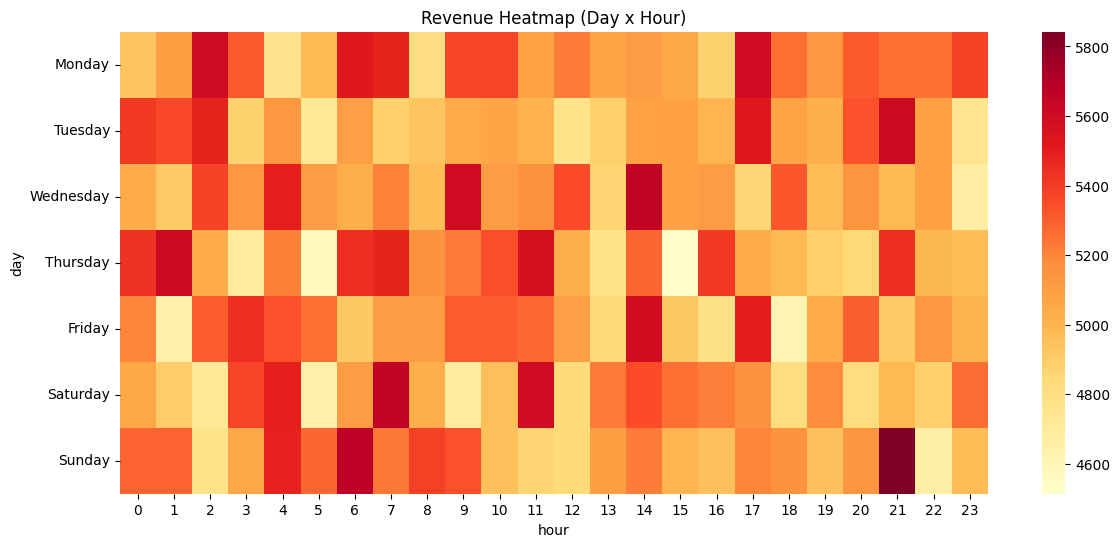

In [16]:
pivot = df.pivot_table(
    index="day",
    columns="hour",
    values="total_price",
    aggfunc="sum"
).reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Revenue Heatmap (Day x Hour)")
plt.show()

In [17]:
kids = df[df['category'].str.contains("kids", case=False)]

kids_stats = kids.groupby("product_name")["total_price"].sum().sort_values(ascending=False)
kids_stats

product_name
Kids Cheeseburger       29888.443013
Kids Nuggets 4pc        29050.842098
Kids Fries              15691.238259
Kids Apple Juice        12869.819159
Unknown Item             1295.626660
20pc Nuggets              191.760000
Double Cheese Burger      170.326620
Bacon King                144.330000
Whopper                   127.330000
Whopper Meal              115.390000
Chicken Royale            101.850000
Big King                   97.860000
Onion Rings (9pc)          71.760000
6pc Nuggets                62.820000
Latte (M)                  59.800000
Coca-Cola Zero (M)         58.850461
Sprite (L)                 58.590000
Coca-Cola (M)              57.270000
Sundae Chocolate           47.310000
Fries (Large)              46.060000
9pc Nuggets                40.410000
Fries (Medium)             36.270000
Sundae Caramel             24.900000
Name: total_price, dtype: float64

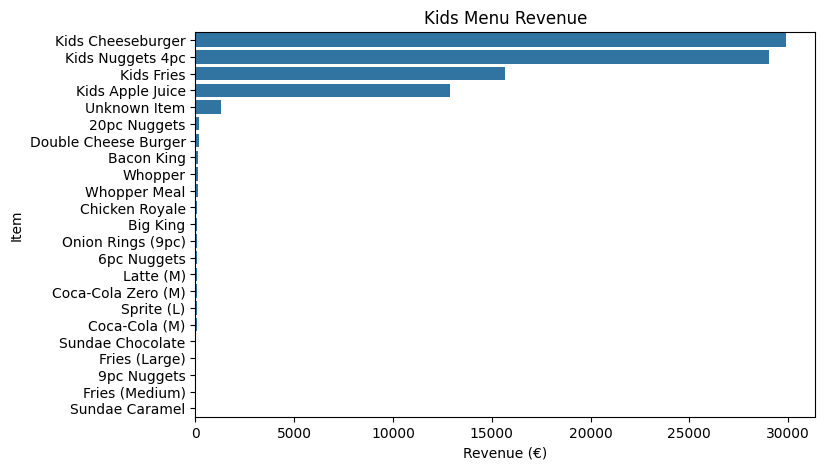

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(x=kids_stats.values, y=kids_stats.index)
plt.title("Kids Menu Revenue")
plt.xlabel("Revenue (€)")
plt.ylabel("Item")
plt.show()